# Task 2: Credit Card Fraud Detection
**CodSoft ML Internship**

Goal: Detect fraudulent credit card transactions using classification algorithms.

## Step 1: Install & Import Libraries

In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from imblearn.over_sampling import SMOTE

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

**How to download the dataset:**
1. Go to: https://www.kaggle.com/datasets/kartik2112/fraud-detection
2. Click **Download**
3. Extract the zip — you'll get `fraudTrain.csv` and `fraudTest.csv`
4. Place both CSV files in the **same folder as this notebook**

In [7]:
train_df = pd.read_csv('fraudTrain.csv')
test_df  = pd.read_csv('fraudTest.csv')

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
train_df.head()

Train shape: (1296675, 23)
Test shape:  (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Step 3: Explore the Data

In [9]:
print('Column names:\n', train_df.columns.tolist())
print('\nData types:\n', train_df.dtypes)
print('\nMissing values:\n', train_df.isnull().sum())

Column names:
 ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Data types:
 Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float

Class distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud percentage: 0.58%


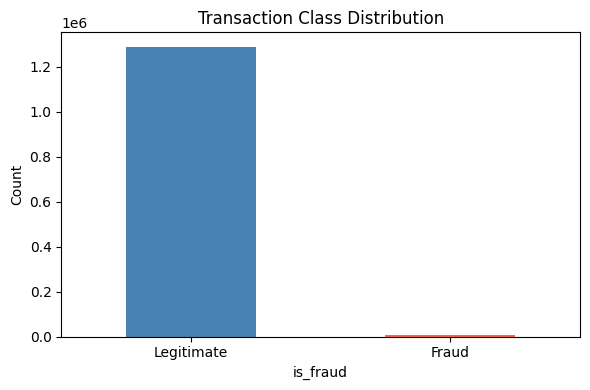

In [11]:
# Check class imbalance
fraud_counts = train_df['is_fraud'].value_counts()
print('Class distribution:')
print(fraud_counts)
print(f'\nFraud percentage: {fraud_counts[1]/len(train_df)*100:.2f}%')

# Plot
plt.figure(figsize=(6, 4))
fraud_counts.plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.title('Transaction Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

## Step 4: Feature Engineering & Preprocessing

In [13]:
# Combine train and test for consistent preprocessing
df = pd.concat([train_df, test_df], ignore_index=True)

# Select relevant numerical + categorical features
features = ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'category', 'gender']
target = 'is_fraud'

df = df[features + [target]].copy()

# Encode categorical columns
df['category'] = df['category'].astype('category').cat.codes
df['gender']   = df['gender'].map({'M': 0, 'F': 1})

df.dropna(inplace=True)
print('Dataset after preprocessing:', df.shape)
df.head()

Dataset after preprocessing: (1852394, 10)


,amt,lat,long,city_pop,unix_time,merch_lat,merch_long,category,gender,is_fraud
0,4.97,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,8,1,0
1,107.23,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,4,1,0
2,220.11,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,0
3,45.00,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,2,0,0
4,41.96,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,9,0,0


## Step 5: Handle Class Imbalance with SMOTE

In [15]:
X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Apply SMOTE to handle imbalance (only on training set)
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE: ', pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 1474194, 1: 7721}
After SMOTE:  {0: 1474194, 1: 442258}


## Step 6: Train & Compare 3 Models

In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test_scaled)
    acc   = accuracy_score(y_test, preds)
    roc   = roc_auc_score(y_test, preds)
    results[name] = {'accuracy': acc, 'roc_auc': roc}
    print(f'{name}: Accuracy={acc:.4f} | ROC-AUC={roc:.4f}')

Logistic Regression: Accuracy=0.9844 | ROC-AUC=0.7912
Decision Tree: Accuracy=0.9836 | ROC-AUC=0.9410
Random Forest: Accuracy=0.9970 | ROC-AUC=0.8926


In [18]:
# Detailed report for best model (by ROC-AUC)
best_name = max(results, key=lambda x: results[x]['roc_auc'])
print(f'Best Model: {best_name}\n')
best_model = models[best_name]
best_preds = best_model.predict(X_test_scaled)

print(classification_report(y_test, best_preds, target_names=['Legitimate', 'Fraud']))

Best Model: Decision Tree

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    368549
       Fraud       0.23      0.90      0.36      1930

    accuracy                           0.98    370479
   macro avg       0.61      0.94      0.68    370479
weighted avg       1.00      0.98      0.99    370479



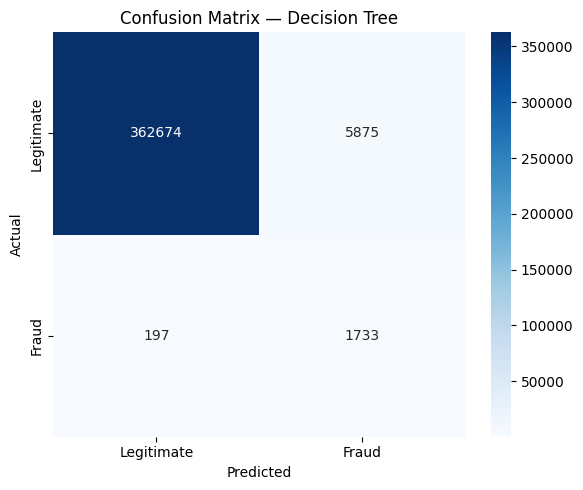

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

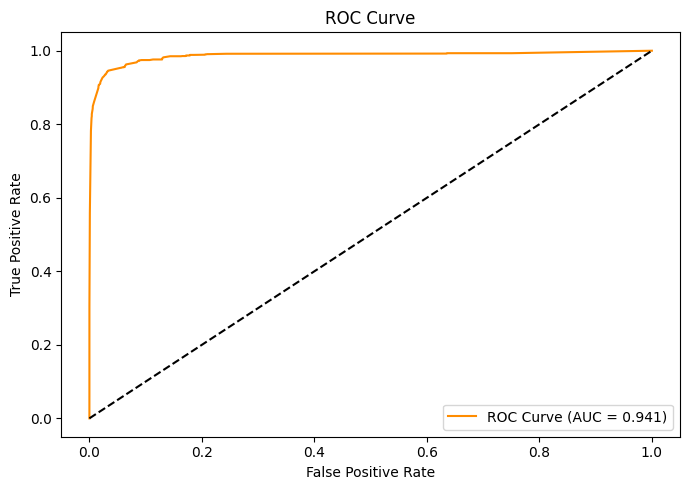

In [22]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test_scaled)[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {results[best_name]["roc_auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [28]:
# Feature Importance (Random Forest)
if best_name == 'Random Forest':
    importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    importances.plot(kind='bar', color='steelblue')
    plt.title('Feature Importances')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()

## ✅ Task 2 Complete!
- Loaded credit card fraud dataset
- Handled severe class imbalance using SMOTE
- Trained Logistic Regression, Decision Tree, Random Forest
- Evaluated using Accuracy, ROC-AUC, Confusion Matrix
- Visualized ROC Curve and Feature Importances